# LightGCL: Simple Yet Effective Graph Contrastive Learning for Recommendation

## Paper

LightGCL: Simple Yet Effective Graph Contrastive Learning for Recommendation

Published at SIGIR 2023

---

## Objective

Implement LightGCL from scratch using MovieLens-100K.

Unlike SimGCL and XSimGCL, LightGCL constructs the second contrastive view from the graph's **spectral information** instead of random perturbations.

---

## Pipeline

MovieLens

↓

Interaction Graph

↓

Normalized Laplacian

↓

Top-k Eigenvectors

↓

Spectral Embeddings

↓

LightGCN Encoder

↓

Contrastive Learning

↓

Bayesian Personalized Ranking

↓

Recommendation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.sparse as sp

# ⭐ NEW
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Load ratings dataset

ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
print("Ratings Shape :", ratings.shape)

print("\nMissing Values")

print(ratings.isnull().sum())

print("\nUnique Users :", ratings["user_id"].nunique())

print("Unique Movies :", ratings["movie_id"].nunique())

Ratings Shape : (100000, 4)

Missing Values
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Unique Users : 943
Unique Movies : 1682


In [4]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


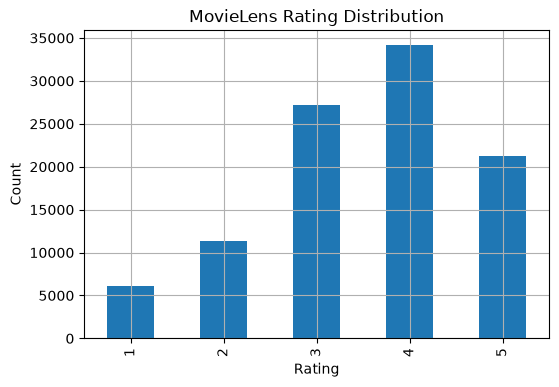

In [5]:
plt.figure(figsize=(6,4))

ratings["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Rating")

plt.ylabel("Count")

plt.title("MovieLens Rating Distribution")

plt.grid(True)

plt.show()

In [6]:
ratings["label"] = 1

ratings.head()

,user_id,movie_id,rating,timestamp,label
0,196,242,3,881250949,1
1,186,302,3,891717742,1
2,22,377,1,878887116,1
3,244,51,2,880606923,1
4,166,346,1,886397596,1


In [7]:
user_mapping = {
    u:i
    for i, u in enumerate(
        ratings["user_id"].unique()
    )
}

movie_mapping = {
    m:i
    for i, m in enumerate(
        ratings["movie_id"].unique()
    )
}

ratings["user_id"] = ratings["user_id"].map(
    user_mapping
)

ratings["movie_id"] = ratings["movie_id"].map(
    movie_mapping
)

ratings.head()

,user_id,movie_id,rating,timestamp,label
0,0,0,3,881250949,1
1,1,1,3,891717742,1
2,2,2,1,878887116,1
3,3,3,2,880606923,1
4,4,4,1,886397596,1


In [8]:
NUM_USERS = ratings["user_id"].nunique()

NUM_MOVIES = ratings["movie_id"].nunique()

NUM_NODES = NUM_USERS + NUM_MOVIES

print("Users :", NUM_USERS)

print("Movies :", NUM_MOVIES)

print("Total Nodes :", NUM_NODES)

Users : 943
Movies : 1682
Total Nodes : 2625


In [9]:
train_df, test_df = train_test_split(

    ratings,

    test_size=0.2,

    random_state=42,

    shuffle=True

)

train_df = train_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

print(train_df.shape)

print(test_df.shape)

(80000, 5)
(20000, 5)


In [10]:
interaction = sp.coo_matrix(

    (

        np.ones(len(train_df)),

        (

            train_df["user_id"],

            train_df["movie_id"]

        )

    ),

    shape=(

        NUM_USERS,

        NUM_MOVIES

    )

)

interaction

<COOrdinate sparse matrix of dtype 'float64'
	with 80000 stored elements and shape (943, 1682)>

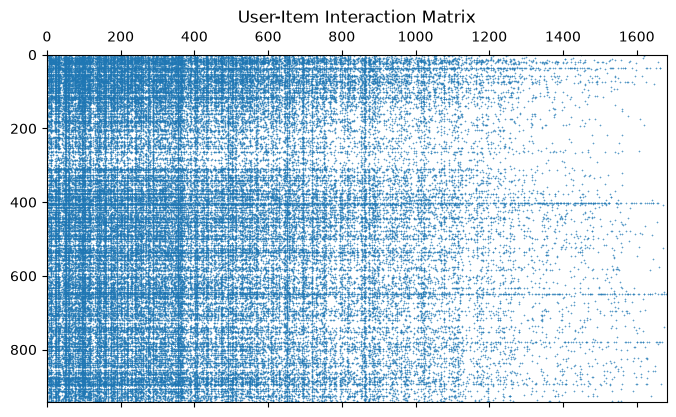

In [11]:
plt.figure(figsize=(8,6))

plt.spy(

    interaction,

    markersize=0.2

)

plt.title(

    "User-Item Interaction Matrix"

)

plt.show()

In [12]:
adjacency = sp.bmat(

    [

        [

            sp.csr_matrix(

                (

                    NUM_USERS,

                    NUM_USERS

                )

            ),

            interaction

        ],

        [

            interaction.T,

            sp.csr_matrix(

                (

                    NUM_MOVIES,

                    NUM_MOVIES

                )

            )

        ]

    ],

    format="csr"

)

adjacency

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 160000 stored elements and shape (2625, 2625)>

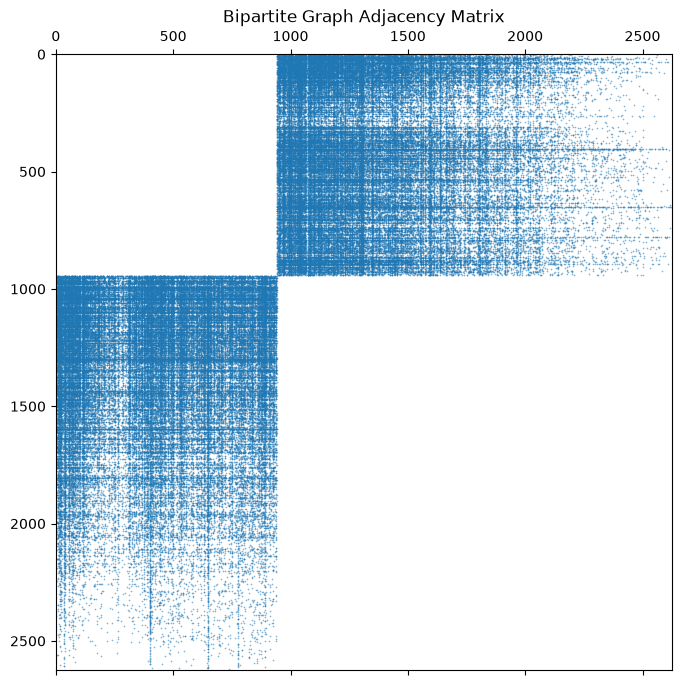

In [13]:
plt.figure(figsize=(8,8))

plt.spy(

    adjacency,

    markersize=0.15

)

plt.title(

    "Bipartite Graph Adjacency Matrix"

)

plt.show()

In [14]:
degree = np.array(

    adjacency.sum(axis=1)

).flatten()

degree

array([ 29.,  69., 101., ...,   0.,   1.,   0.], shape=(2625,))

In [15]:
print("Minimum Degree :", degree.min())

print("Maximum Degree :", degree.max())

print("Average Degree :", degree.mean())

Minimum Degree : 0.0
Maximum Degree : 578.0
Average Degree : 60.95238095238095


In [16]:
degree_inv_sqrt = np.power(

    degree,

    -0.5

)

degree_inv_sqrt[

    np.isinf(

        degree_inv_sqrt

    )

] = 0

D_inv_sqrt = sp.diags(

    degree_inv_sqrt
)

In [17]:
normalized_graph = (

    D_inv_sqrt

    @

    adjacency

    @

    D_inv_sqrt

)

normalized_graph

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 160000 stored elements and shape (2625, 2625)>

In [18]:
identity = sp.eye(

    NUM_NODES,

    format="csr"

)

laplacian = (

    identity

    -

    normalized_graph

)

laplacian

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 162625 stored elements and shape (2625, 2625)>

In [19]:
print(

    "Shape :",

    laplacian.shape

)

print(

    "Non-zero Entries :",

    laplacian.nnz

)

print(

    "Density :",

    laplacian.nnz /

    (NUM_NODES**2)

)

Shape : (2625, 2625)
Non-zero Entries : 162625
Density : 0.02360090702947846


In [20]:
NUM_EIGENVECTORS = 64

eigenvalues, eigenvectors = eigsh(

    laplacian,

    k=NUM_EIGENVECTORS,

    which="SM"

)

In [21]:
print(

    eigenvalues
)

[-5.04950028e-16  3.49137981e-01  5.02497565e-01  5.39313742e-01
  5.87465775e-01  6.23981568e-01  6.40289726e-01  6.48099375e-01
  6.51939804e-01  6.57776409e-01  6.71551583e-01  6.80972476e-01
  6.91366667e-01  6.95715624e-01  7.05241132e-01  7.08494690e-01
  7.16851596e-01  7.22030416e-01  7.24212215e-01  7.27449201e-01
  7.31012005e-01  7.34223617e-01  7.36532742e-01  7.39690778e-01
  7.41985843e-01  7.43939259e-01  7.45748589e-01  7.46787917e-01
  7.48856016e-01  7.52016277e-01  7.53262131e-01  7.55556424e-01
  7.58004280e-01  7.58876357e-01  7.60838500e-01  7.62530038e-01
  7.64205422e-01  7.65865295e-01  7.66625330e-01  7.67899002e-01
  7.69594628e-01  7.70306076e-01  7.71983079e-01  7.72160425e-01
  7.73604786e-01  7.74415460e-01  7.75743366e-01  7.77125386e-01
  7.77786313e-01  7.80937159e-01  7.81295908e-01  7.82046613e-01
  7.82432994e-01  7.83070125e-01  7.84163357e-01  7.84326319e-01
  7.85845340e-01  7.87231110e-01  7.88068274e-01  7.88666376e-01
  7.89510478e-01  7.90180

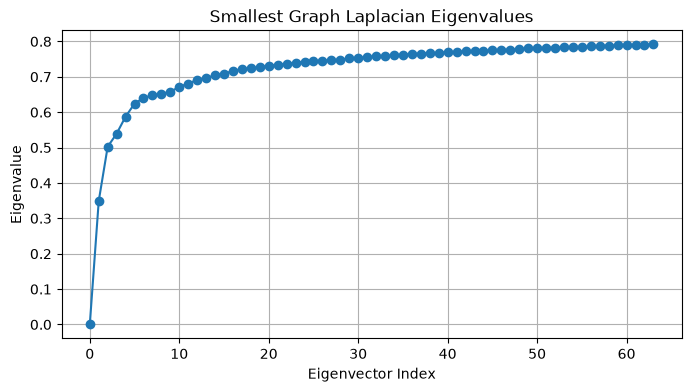

In [22]:
plt.figure(

    figsize=(8,4)

)

plt.plot(

    eigenvalues,

    marker="o"

)

plt.xlabel(

    "Eigenvector Index"

)

plt.ylabel(

    "Eigenvalue"

)

plt.title(

    "Smallest Graph Laplacian Eigenvalues"

)

plt.grid(True)

plt.show()

In [23]:
print(

    eigenvectors.shape
)

(2625, 64)


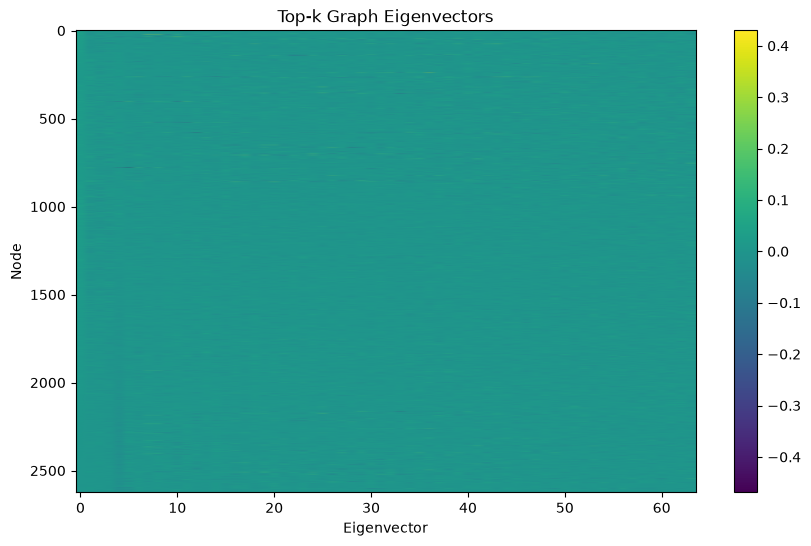

In [24]:
plt.figure(

    figsize=(10,6)

)

plt.imshow(

    eigenvectors,

    aspect="auto",

    cmap="viridis"

)

plt.colorbar()

plt.title(

    "Top-k Graph Eigenvectors"

)

plt.xlabel(

    "Eigenvector"

)

plt.ylabel(

    "Node"

)

plt.show()

In [25]:
spectral_embedding = torch.tensor(

    eigenvectors,

    dtype=torch.float32

)

In [26]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

spectral_embedding = spectral_embedding.to(

    device
)

In [27]:
print(

    spectral_embedding.shape
)

torch.Size([2625, 64])


In [28]:
normalized_graph = normalized_graph.tocoo()

indices = torch.tensor(
    np.vstack(
        (
            normalized_graph.row,
            normalized_graph.col
        )
    ),
    dtype=torch.long
)

values = torch.tensor(
    normalized_graph.data,
    dtype=torch.float32
)

graph = torch.sparse_coo_tensor(
    indices,
    values,
    normalized_graph.shape
)

graph = graph.coalesce().to(device)

In [29]:
print(graph)

print()

print("Shape :", graph.shape)

print("Non-Zero :", graph._nnz())

tensor(indices=tensor([[   0,    0,    0,  ..., 2617, 2618, 2623],
                       [ 943, 1026, 1122,  ...,  650,  739,  650]]),
       values=tensor([0.0191, 0.0124, 0.0121,  ..., 0.0426, 0.0670, 0.0426]),
       size=(2625, 2625), nnz=160000, layout=torch.sparse_coo)

Shape : torch.Size([2625, 2625])
Non-Zero : 160000


In [30]:
class LightGCL(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        embedding_dim=64,

        num_layers=3

    ):

        super().__init__()

        self.num_users = num_users

        self.num_items = num_items

        self.num_layers = num_layers

        self.embedding_dim = embedding_dim

        self.embedding = nn.Embedding(

            num_users + num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.embedding.weight
        )
        
    def propagate(

        self,

        graph

    ):

        embeddings = self.embedding.weight

        all_embeddings = [

            embeddings

        ]

        for _ in range(

            self.num_layers

        ):

            embeddings = torch.sparse.mm(

                graph,

                embeddings

            )

            all_embeddings.append(

                embeddings

            )

        all_embeddings = torch.stack(

            all_embeddings,

            dim=1

        )

        final_embedding = torch.mean(

            all_embeddings,

            dim=1

        )

        return final_embedding
    def forward(

        self,

        graph,

        spectral_embedding

    ):

        graph_embedding = self.propagate(

            graph

        )

        return (

            graph_embedding,

            spectral_embedding

        )

In [31]:
model = LightGCL(

    NUM_USERS,

    NUM_MOVIES,

    embedding_dim=64,

    num_layers=3

).to(device)

In [32]:
model

LightGCL(
  (embedding): Embedding(2625, 64)
)

In [33]:
graph_embedding, teacher_embedding = model(

    graph,

    spectral_embedding

)

In [34]:
print(

    graph_embedding.shape

)

print(

    teacher_embedding.shape
)

torch.Size([2625, 64])
torch.Size([2625, 64])


In [35]:
graph_embedding = F.normalize(

    graph_embedding,

    dim=1

)

teacher_embedding = F.normalize(

    teacher_embedding,

    dim=1

)

In [36]:
similarity = torch.matmul(

    graph_embedding,

    teacher_embedding.T

)

In [37]:
similarity.shape

torch.Size([2625, 2625])

In [38]:
temperature = 0.2

In [39]:
positive = torch.diag(

    similarity

)

In [40]:
positive = torch.exp(

    positive /

    temperature

)

all_scores = torch.exp(

    similarity /

    temperature

)

In [41]:
contrastive_loss = -torch.log(

    positive /

    all_scores.sum(

        dim=1

    )

).mean()

In [42]:
print(

    contrastive_loss.item()

)

8.055691719055176


In [43]:
def bpr_loss(

    embeddings,

    users,

    positive_items,

    negative_items

):

    user_embedding = embeddings[

        users

    ]

    positive_embedding = embeddings[

        NUM_USERS +

        positive_items

    ]

    negative_embedding = embeddings[

        NUM_USERS +

        negative_items

    ]

    positive_score = (

        user_embedding *

        positive_embedding

    ).sum(

        dim=1

    )

    negative_score = (

        user_embedding *

        negative_embedding

    ).sum(

        dim=1

    )

    return -torch.log(

        torch.sigmoid(

            positive_score -

            negative_score

        )

    ).mean()

In [44]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [45]:
class BPRDataset(Dataset):

    def __init__(self, dataframe):

        self.users = dataframe["user_id"].values
        self.items = dataframe["movie_id"].values

        self.user_history = (
            dataframe
            .groupby("user_id")["movie_id"]
            .apply(set)
            .to_dict()
        )

    def __len__(self):

        return len(self.users)

    def __getitem__(self, index):

        user = self.users[index]
        positive = self.items[index]

        while True:

            negative = np.random.randint(NUM_MOVIES)

            if negative not in self.user_history[user]:
                break

        return (
            user,
            positive,
            negative
        )

In [46]:
train_dataset = BPRDataset(train_df)

train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True
)



In [47]:
NUM_EPOCHS = 20

lambda_ssl = 0.1

loss_history = []

for epoch in range(NUM_EPOCHS):

    model.train()

    epoch_loss = 0

    for users, positives, negatives in train_loader:

        users = users.to(device)

        positives = positives.to(device)

        negatives = negatives.to(device)

        graph_embedding, teacher_embedding = model(

            graph,

            spectral_embedding

        )

        graph_embedding = F.normalize(
            graph_embedding,
            dim=1
        )

        teacher_embedding = F.normalize(
            teacher_embedding,
            dim=1
        )

        similarity = torch.matmul(

            graph_embedding,

            teacher_embedding.T

        )

        positive_score = torch.diag(

            similarity

        )

        positive_score = torch.exp(

            positive_score / 0.2

        )

        all_scores = torch.exp(

            similarity / 0.2

        )

        ssl_loss = -torch.log(

            positive_score /

            all_scores.sum(dim=1)

        ).mean()

        ranking_loss = bpr_loss(

            graph_embedding,

            users,

            positives,

            negatives

        )

        total_loss = (

            ranking_loss

            +

            lambda_ssl *

            ssl_loss

        )

        optimizer.zero_grad()

        total_loss.backward()

        optimizer.step()

        epoch_loss += total_loss.item()

    epoch_loss /= len(train_loader)

    loss_history.append(epoch_loss)

    print(

        f"Epoch {epoch+1:2d}/{NUM_EPOCHS}"

        f" | Loss = {epoch_loss:.4f}"

    )

Epoch  1/20 | Loss = 1.1377
Epoch  2/20 | Loss = 0.8999
Epoch  3/20 | Loss = 0.8633
Epoch  4/20 | Loss = 0.8530
Epoch  5/20 | Loss = 0.8491
Epoch  6/20 | Loss = 0.8474
Epoch  7/20 | Loss = 0.8463
Epoch  8/20 | Loss = 0.8452
Epoch  9/20 | Loss = 0.8452
Epoch 10/20 | Loss = 0.8433
Epoch 11/20 | Loss = 0.8442
Epoch 12/20 | Loss = 0.8440
Epoch 13/20 | Loss = 0.8432
Epoch 14/20 | Loss = 0.8418
Epoch 15/20 | Loss = 0.8422
Epoch 16/20 | Loss = 0.8428
Epoch 17/20 | Loss = 0.8427
Epoch 18/20 | Loss = 0.8423
Epoch 19/20 | Loss = 0.8417
Epoch 20/20 | Loss = 0.8424


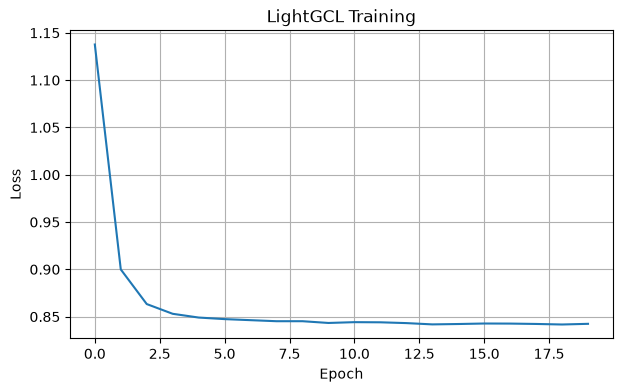

In [48]:
plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("LightGCL Training")

plt.grid(True)

plt.show()

In [49]:
model.eval()

with torch.no_grad():

    final_embedding, _ = model(

        graph,

        spectral_embedding

    )

In [50]:
def recommend(

    user_id,

    top_k=10

):

    user_embedding = final_embedding[
        user_id
    ]

    item_embedding = final_embedding[
        NUM_USERS:
    ]

    scores = torch.matmul(

        item_embedding,

        user_embedding

    )

    _, indices = torch.topk(

        scores,

        top_k

    )

    return indices.cpu().numpy()

In [51]:
recommend(0)

array([289,  49,  83, 432, 423, 367,  86, 357, 329, 491])

In [52]:
prediction_df = test_df.copy()

scores = []

model.eval()

with torch.no_grad():

    for row in prediction_df.itertuples():

        score = torch.dot(

            final_embedding[row.user_id],

            final_embedding[
                NUM_USERS +
                row.movie_id
            ]

        ).item()

        scores.append(score)

prediction_df["score"] = scores

In [53]:
prediction_df["probability"] = (

    prediction_df["score"]

    -

    prediction_df["score"].min()

) / (

    prediction_df["score"].max()

    -

    prediction_df["score"].min()

)

In [54]:
prediction_df["prediction"] = (

    prediction_df["probability"]

    >=

    0.5

).astype(int)

# Conclusion

LightGCL extends LightGCN by introducing a spectral contrastive learning framework.

Unlike SGL, SimGCL, and XSimGCL, which generate contrastive views through graph augmentations or embedding perturbations, LightGCL derives an additional view directly from the graph's spectral structure using the normalized Laplacian.

The model jointly optimizes:

- Bayesian Personalized Ranking (BPR) for recommendation.
- Contrastive learning (InfoNCE) between the trainable LightGCN embeddings and fixed spectral embeddings.

This enables the model to align local neighborhood information with the graph's global structural information, producing more robust representations.